In [70]:
import os
import numpy as np
import pandas as pd
import cv2 as cv
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.utils import image_dataset_from_directory
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, AveragePooling2D, Dropout, LeakyReLU, RandomFlip, RandomRotation, Input, BatchNormalization, RandomContrast, RandomCrop, RandomZoom, RandomBrightness
from keras.optimizers import  Adam
from keras.models import load_model
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [71]:
# Get images directories and read csv files 

current_dir = os.getcwd()

train_data_dir =  os.path.join(current_dir, "train_images")
val_data_dir =  os.path.join(current_dir, "val_images")
test_data_dir =  os.path.join(current_dir, "test_images")

train_csv = pd.read_csv('train.csv')
val_csv = pd.read_csv('val.csv')
test_csv = pd.read_csv('test.csv')

In [72]:
# Get the the images with their labels and put them in a dataset
def get_images(data_dir, images_csv ): 
     
    images = []
    labels = []
    
    # Iterate through file names from the images directory
    for img_name in os.listdir(data_dir):
        
        #read the image
        img = cv.imread(os.path.join(data_dir, img_name))
        
        # if the image is full black, ignore it
        if np.all(img== 0):
            continue
        
        # append the image and the it's label to list
        images.append(img)    
        labels.append(images_csv[images_csv['Image']==img_name]['Class'].iloc[0])
        
    
    # Create the dataset object with the images and labels and combine them
    images = tf.data.Dataset.from_tensor_slices((tf.constant(np.array(images))))
    labels_dataset = tf.data.Dataset.from_tensor_slices(labels)
    dataset = tf.data.Dataset.zip((images, labels_dataset))

    # Prepare the dataset
    dataset = dataset.shuffle(buffer_size=1000) 
    dataset = dataset.batch(32)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
               
    return dataset 

# Create the train and the validation datasets
train_dataset = get_images(train_data_dir,train_csv)
val_dataset = get_images(val_data_dir, val_csv)

In [60]:
# Create the model for data augmentation and map the method to train dataset
data_aug = tf.keras.Sequential([
    RandomFlip(mode="horizontal", seed=1),
    RandomContrast(factor=0.8, seed=1),
    RandomBrightness(factor=0.8, seed=1),
    RandomRotation(0.1,
                   fill_mode='reflect',
                   interpolation='bilinear',
                   seed=1)
    ])


def data_augmentation(image, label):
    
    image = data_aug(image)
    
    return image, label


train_dataset = train_dataset.map(data_augmentation)

In [61]:
# Normalize images
def normalize_images(image, label = None):
    
    image = tf.image.per_image_standardization(image)
    
    if label != None:
        return image, label
    
    return image



train_dataset.map(normalize_images)
val_dataset.map(normalize_images)

<MapDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [1]:
#Build the model and create the model

def build_model():
    
    model = Sequential()
    model.add(tf.keras.Input(shape=(64,64,3)))
    model.add(BatchNormalization(axis=-1))
    
    model.add(Conv2D(filters=64, kernel_size=(3,3), input_shape=(64,64,3), padding='same', activation=LeakyReLU(alpha=0.1)))  
    model.add(BatchNormalization(axis=-1))
    
    model.add(AveragePooling2D((2,2)))
    model.add(Conv2D(128, (3,3), padding='same', activation=LeakyReLU(alpha=0.1)))
    model.add(BatchNormalization(axis=-1))
    
    model.add(AveragePooling2D((2,2)))
    model.add(Conv2D(128, (3,3), padding='same', activation=LeakyReLU(alpha=0.1)))
    model.add(BatchNormalization(axis=-1))
    
    model.add(AveragePooling2D((2,2)))
    model.add(Conv2D(128, (3,3), padding='same', activation=LeakyReLU(alpha=0.1)))
    model.add(BatchNormalization(axis=-1))
    
    model.add(AveragePooling2D((2,2)))
    model.add(BatchNormalization(axis=-1))
    
    model.add(Flatten())
    model.add(Dense(512, activation= LeakyReLU(alpha=0.1)))
    model.add(Dropout(0.5))
    model.add(Dense(100,activation="softmax"))
    model.build()

    return model

model = build_model()
model.summary()

NameError: name 'Sequential' is not defined

In [78]:
from keras.optimizers import Adam

# Compile the model
optimizer = Adam(learning_rate=0.0001)

model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [79]:
# Create the callbacks directory for the model
checkpoint_dir = './model_checkpoints'
if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir) 


checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath = checkpoint_dir + '/model.{epoch:05d}.hdf5'
)

In [80]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir = os.path.join('logs'),
    write_graph = True,
    update_freq = 'epoch'
)

# Train the model
history = model.fit(train_dataset,
            epochs=80, batch_size=32, initial_epoch=0,
            callbacks=[checkpoint_callback, tensorboard_callback],
            validation_data= val_dataset)

Epoch 1/80


406/406 [==============================] - 10s 16ms/step - loss: 5.1928 - accuracy: 0.0520 - val_loss: 3.7397 - val_accuracy: 0.1734
Epoch 2/80
406/406 [==============================] - 6s 15ms/step - loss: 4.0407 - accuracy: 0.1062 - val_loss: 3.0786 - val_accuracy: 0.2852
Epoch 3/80
406/406 [==============================] - 6s 15ms/step - loss: 3.6336 - accuracy: 0.1632 - val_loss: 2.7725 - val_accuracy: 0.3649
Epoch 4/80
406/406 [==============================] - 7s 16ms/step - loss: 3.2802 - accuracy: 0.2211 - val_loss: 2.4328 - val_accuracy: 0.4160
Epoch 5/80
406/406 [==============================] - 6s 15ms/step - loss: 3.0584 - accuracy: 0.2518 - val_loss: 2.2470 - val_accuracy: 0.4602
Epoch 6/80
406/406 [==============================] - 6s 14ms/step - loss: 2.8422 - accuracy: 0.2911 - val_loss: 2.0537 - val_accuracy: 0.4757
Epoch 7/80
406/406 [==============================] - 6s 14ms/step - loss: 2.6653 - accuracy: 0.3225 - val_loss: 1.9345 - val_accuracy: 0.5063
Epoch 8/8

KeyboardInterrupt: 

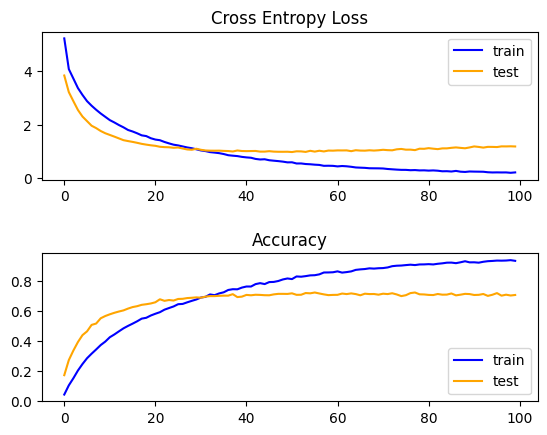

In [46]:
# Plot the model performance
def summarize_diagnostics(history):
    # loss
	plt.subplot(211)
	plt.title('Cross Entropy Loss')
	plt.plot(history.history['loss'], color='blue', label='train')
	plt.plot(history.history['val_loss'], color='orange', label='test')
	plt.legend(['train', 'test'])

	# accuracy
	plt.subplot(212)
	plt.title('Accuracy')
	plt.plot(history.history['accuracy'], color='blue', label='train')
	plt.plot(history.history['val_accuracy'], color='orange', label='test')
	plt.legend(['train', 'test'])
	plt.legend(['train', 'test'], loc='lower right')

	plt.subplots_adjust(hspace=0.5)


plt.show()

# learning curves
summarize_diagnostics(history)

In [30]:
# Load the model from best epoch
def load_best_model(best_epoch=0):
    
    best_model = load_model('./model_checkpoints/model.%05d.hdf5' % best_epoch)
    print('./model_checkpoints/model.%05d.hdf5' % best_epoch)
    
    return best_model 

model = load_best_model(best_epoch=56)

./model_checkpoints/model.00056.hdf5


In [206]:
# Get the test data
def get_test_images(data_dir, test_csv ): 
     
    images = []
    labels = []
    for img_name in test_csv['Image']:

        img = cv.imread(os.path.join(data_dir, img_name))
        images.append(img)    
               
    return np.array(images)

test_images = get_test_images(test_data_dir, test_csv)

In [207]:
len(test_csv)

5000

In [209]:
# Create the submission file
def create_submission(name, best_epoch, test_csv=test_csv):
    
    test_images = get_test_images(test_data_dir, test_csv)

    best_model = load_best_model(best_epoch)
    test_predict = best_model.predict(test_images)
    test_predict = np.argmax(test_predict, axis=-1)
    test_csv['Class'] = test_predict
    
    test_csv.to_csv(f'submissions\\{name}', index=False)
    
create_submission(name='sub_5.csv', best_epoch=60)
    

./model_checkpoints/model.00060.hdf5
157/157 [==============================] - 1s 7ms/step
